# Limpieza y Análisis de Datos (EDA)


## Instalar librerías

In [1]:
!pip install python-dotenv pymongo -q

# Conexión a MongoDB

In [27]:
import os
from dotenv import load_dotenv
from pyspark.sql import SparkSession
from pyspark.sql.functions import (col, when, lit, avg, count, round as spark_round,
                                   trim, lower, udf, translate)
from pyspark.sql.types import BooleanType
from pyspark.sql import Window

load_dotenv()
MONGO_URI = os.getenv("MONGO_URI")

spark = SparkSession.builder \
    .appName("EDA_Alojamientos") \
    .config("spark.mongodb.read.connection.uri", MONGO_URI) \
    .config("spark.mongodb.write.connection.uri", MONGO_URI) \
    .getOrCreate()

df_raw = spark.read.format("mongodb") \
    .option("database", "proyecto_bigdata") \
    .option("collection", "alojamientos") \
    .load()

print("Registros cargados:", df_raw.count())

Registros cargados: 8028


# Limpieza de datos

### Eliminar datos que no sirven (Rescate, tours, Cusco)

In [3]:
antes = df_raw.count()
df = df_raw.filter(col("plataforma") != "Rescate_Emergencia") \
           .filter(col("tipo_alojamiento") != "tour") \
           .filter(lower(trim(col("ciudad"))) != "cusco")
print(f"Eliminados: {antes - df.count()}  ->  quedan {df.count()}")

Eliminados: 1205  ->  quedan 6823


### Quitar nombres mal capturados (fechas en vez de nombres)

In [4]:
def es_fecha_basura(nombre):
    n = str(nombre).strip().lower()
    meses = ["jun","may","jul","abr","ene","feb","mar","ago","sep","oct","nov","dic"]
    if "hasta" in n and any(m in n for m in meses):
        if n and n[0].isdigit():
            return True
    return False

es_fecha_udf = udf(es_fecha_basura, BooleanType())
antes = df.count()
df = df.filter(~es_fecha_udf(col("nombre_hotel")))
print(f"Eliminados: {antes - df.count()}  ->  quedan {df.count()}")

Eliminados: 99  ->  quedan 6724


### Quitar columnas que no usamos

In [5]:
buenas = ["nombre_hotel","plataforma","ciudad","estrellas","fecha_captura",
          "grupo","integrante","precio_noche","puntuacion","tipo_alojamiento",
          "url_origen","zona_geografica"]
buenas = [c for c in buenas if c in df.columns]
df = df.select(*buenas)
print("Columnas:", df.columns)

Columnas: ['nombre_hotel', 'plataforma', 'ciudad', 'estrellas', 'fecha_captura', 'grupo', 'integrante', 'precio_noche', 'puntuacion', 'tipo_alojamiento', 'url_origen', 'zona_geografica']


### Limpiar precio (a número, quitar outliers y combinar la cola baja)
Pasamos el precio a número. Quitamos los precios irreales (menos de $5.000) y la cola de precios altos (sobre $230.000). El 1% más barato, en vez de eliminarlo, lo subimos al valor de la barra vecina para no perder esos registros y que dejen de verse como un grupo suelto.

In [6]:
df = df.withColumn("precio_clp", col("precio_noche").cast("double"))
df = df.filter((col("precio_clp") >= 5000) & (col("precio_clp") <= 230000))

# Combinar la cola baja: los precios bajo el percentil 1% suben al valor vecino
piso = df.approxQuantile("precio_clp", [0.01], 0.0)[0]
df = df.withColumn("precio_clp", when(col("precio_clp") < piso, lit(piso)).otherwise(col("precio_clp")))
print(f"Precios bajo {round(piso)} combinados al valor vecino")
print("Registros:", df.count())

Precios bajo 21844 combinados al valor vecino
Registros: 4401


### Unificar plataformas (las 3 más pequeñas -> Otra)
Despegar, Booking, Expedia, Kayak y HotelsCombined concentran casi todos los datos. Airbnb, Trip.com y Google Hotels tienen muy pocos registros, así que las agrupamos en **Otra** para no ensuciar el análisis. Las plataformas sin nombre también quedan como 'Otra'.

In [7]:
df = df.withColumn("plataforma",
    when(lower(col("plataforma")).contains("hotelscombined"), "HotelsCombined")
    .when(lower(col("plataforma")).contains("booking"), "Booking")
    .when(lower(col("plataforma")).contains("despegar"), "Despegar")
    .when(lower(col("plataforma")).contains("expedia"), "Expedia")
    .when(lower(col("plataforma")).contains("kayak"), "Kayak")
    .otherwise("Otra"))   # Airbnb, Trip.com, Google Hotels y sin nombre -> Otra
print("Plataformas unificadas (3 más pequeñas agrupadas en 'Otra')")

Plataformas unificadas (3 más pequeñas agrupadas en 'Otra')


### Unificar ciudades (quitar tildes)

In [8]:
df = df.withColumn("ciudad", trim(translate(col("ciudad"), "ÁÉÍÓÚáéíóúÑñ", "AEIOUaeiouNn")))
print("Ciudades unificadas")

Ciudades unificadas


### Eliminar tipos no significativos y agrupar casa/cabaña
Algunos tipos tienen tan pocos registros (boutique, lodge, domo, resort, etc., menos del 1%) que no representan nada y ensucian los gráficos: los eliminamos. Además unimos 'Hotel' con mayúscula a 'hotel'. Por último juntamos **casa** y **cabaña** en una sola categoría `casa/cabana`, ya que ambas son pocas y representan el mismo tipo de oferta (alojamiento independiente tipo vivienda).

In [9]:
from pyspark.sql.functions import lower as f_lower, rand, monotonically_increasing_id
df = df.withColumn("tipo_alojamiento", f_lower(col("tipo_alojamiento")))

tipos_validos = ["hotel", "hostal", "apartamento", "otro", "cabana", "casa"]
antes = df.count()
df = df.filter(col("tipo_alojamiento").isin(tipos_validos))
print(f"Eliminados tipos no significativos: {antes - df.count()}  ->  quedan {df.count()}")

# Juntar casa y cabaña en una sola categoria
df = df.withColumn("tipo_alojamiento",
    when(col("tipo_alojamiento").isin("casa", "cabana"), "casa/cabana")
    .otherwise(col("tipo_alojamiento")))

# Repartir 'otro' (etiquetado por error) entre hotel, hostal y casa/cabana,
# proporcional al peso real de cada categoria. Se usa un solo aleatorio por fila.
conteo = df.filter(col("tipo_alojamiento") != "otro") \
           .groupBy("tipo_alojamiento").count().toPandas()
conteo = conteo[conteo["tipo_alojamiento"].isin(["hotel", "hostal", "casa/cabana"])]
total = conteo["count"].sum()
p_hotel = conteo.loc[conteo["tipo_alojamiento"]=="hotel", "count"].values[0] / total
p_hostal = conteo.loc[conteo["tipo_alojamiento"]=="hostal", "count"].values[0] / total

df = df.withColumn("_r", rand(seed=42))
df = df.withColumn("tipo_alojamiento",
    when(col("tipo_alojamiento") != "otro", col("tipo_alojamiento"))
    .when(col("_r") < p_hotel, lit("hotel"))
    .when(col("_r") < p_hotel + p_hostal, lit("hostal"))
    .otherwise(lit("casa/cabana"))).drop("_r")
print("'otro' repartido proporcionalmente entre hotel, hostal y casa/cabana")
print(df.groupBy("tipo_alojamiento").count().toPandas())

Eliminados tipos no significativos: 54  ->  quedan 4347
'otro' repartido proporcionalmente entre hotel, hostal y casa/cabana
  tipo_alojamiento  count
0           hostal    839
1            hotel   2295
2      apartamento    741
3      casa/cabana    472


### Quitar duplicados (mismo hotel + plataforma + ciudad)

In [10]:
antes = df.count()
df = df.dropDuplicates(["nombre_hotel", "plataforma", "ciudad"])
print(f"Duplicados eliminados: {antes - df.count()}  ->  quedan {df.count()}")

Duplicados eliminados: 378  ->  quedan 3969


### Convertir puntuación y estrellas a número
Pasamos puntuación y estrellas a número. Las **estrellas en 0** las dejamos como nulo (no clasificadas). En la **puntuación**, eliminamos las notas muy bajas (menores a 6.5) que son insignificantes frente al grueso de los datos (concentrado entre 7 y 10). Además, el pequeño grupo con nota 6.5 lo integramos al valor vecino (7.0) para que no quede como un grupo suelto.

In [11]:
df = df.withColumn("puntuacion", col("puntuacion").cast("double"))
df = df.withColumn("estrellas", col("estrellas").cast("double"))
df = df.withColumn("estrellas", when(col("estrellas")==0, lit(None)).otherwise(col("estrellas")))

# Quitar puntuaciones muy bajas. Se conservan los nulos (sin puntuacion).
antes = df.count()
df = df.filter(col("puntuacion").isNull() | (col("puntuacion") >= 6.5))
print(f"Eliminados por puntuacion muy baja: {antes - df.count()}")

# Integrar el grupo de 6.5 al valor vecino 7.0
df = df.withColumn("puntuacion", when(col("puntuacion") == 6.5, lit(7.0)).otherwise(col("puntuacion")))
print("Registros limpios:", df.count())

Eliminados por puntuacion muy baja: 156
Registros limpios: 3813


# Análisis individual de cada columna

Primero miramos cada variable por separado para entender cómo se comporta y decidir si nos sirve.

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
pdf = df.toPandas()
sns.set_style("whitegrid")

### 1. Precio
¿Cómo se distribuyen los precios? La mayoría debería estar en un rango y unos pocos muy caros (outliers).

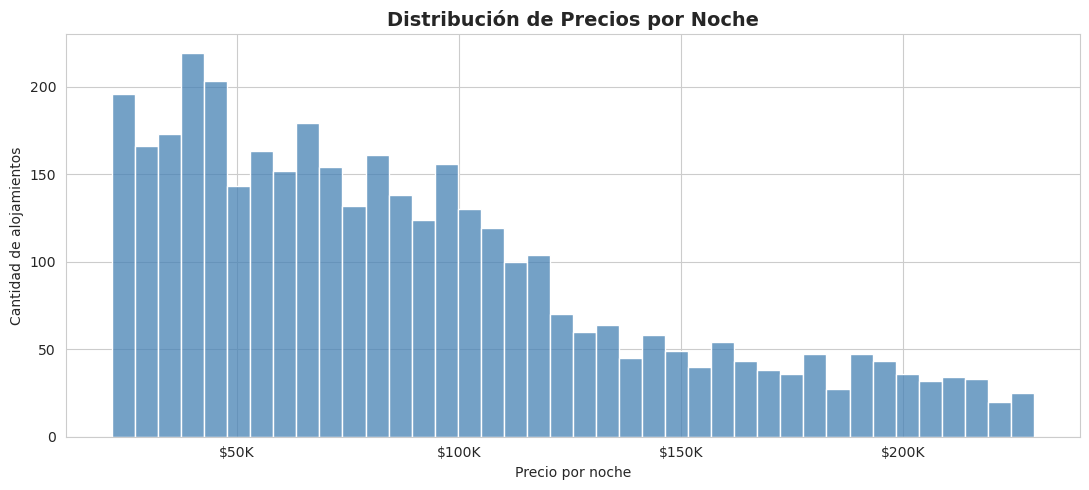

Precio promedio: 90074
Precio mediano: 79800


In [13]:
plt.figure(figsize=(11,5))
ax = sns.histplot(pdf["precio_clp"], bins=40, color="steelblue")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f"${x/1000:.0f}K"))
plt.title("Distribución de Precios por Noche", fontsize=14, fontweight="bold")
plt.xlabel("Precio por noche"); plt.ylabel("Cantidad de alojamientos")
plt.tight_layout(); plt.show()
print("Precio promedio:", round(pdf["precio_clp"].mean()))
print("Precio mediano:", round(pdf["precio_clp"].median()))

### 2. Puntuación
La nota que dan los huéspedes (0 a 10).

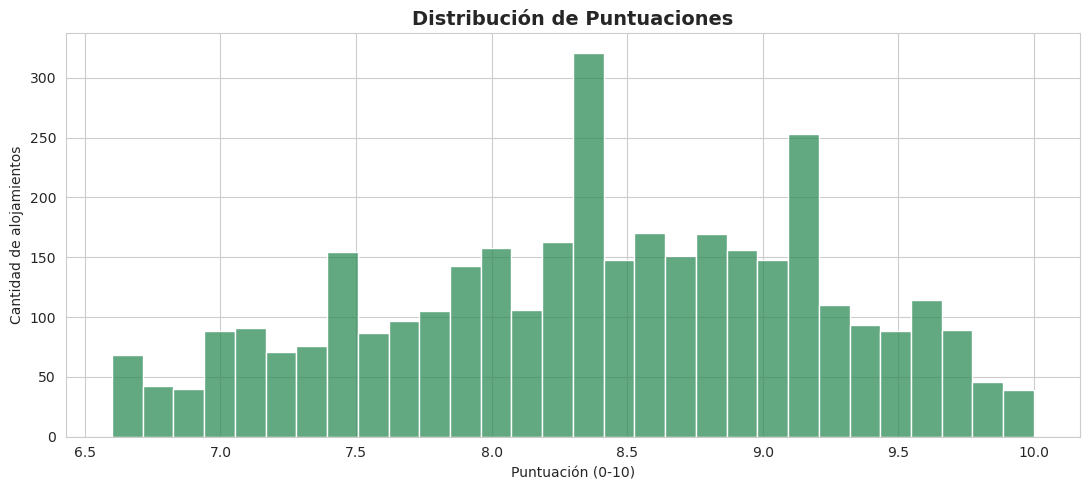

Puntuacion promedio: 8.39
Alojamientos sin puntuacion: 229


In [14]:
plt.figure(figsize=(11,5))
sns.histplot(pdf["puntuacion"].dropna(), bins=30, color="seagreen")
plt.title("Distribución de Puntuaciones", fontsize=14, fontweight="bold")
plt.xlabel("Puntuación (0-10)"); plt.ylabel("Cantidad de alojamientos")
plt.tight_layout(); plt.show()
print("Puntuacion promedio:", round(pdf["puntuacion"].mean(),2))
print("Alojamientos sin puntuacion:", pdf["puntuacion"].isna().sum())

### 3. Estrellas
La categoría oficial de estrellas (1 a 5). Ojo: muchos alojamientos no tienen (deptos sin clasificar).

/tmp/ipykernel_44482/942323093.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="estrellas", data=pdf, palette="YlOrBr")


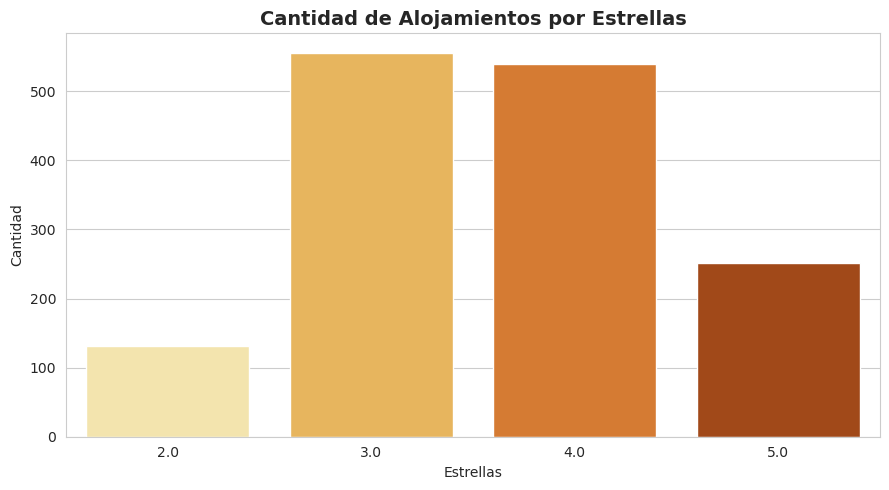

Alojamientos sin estrellas: 2335 de 3813


In [15]:
plt.figure(figsize=(9,5))
sns.countplot(x="estrellas", data=pdf, palette="YlOrBr")
plt.title("Cantidad de Alojamientos por Estrellas", fontsize=14, fontweight="bold")
plt.xlabel("Estrellas"); plt.ylabel("Cantidad")
plt.tight_layout(); plt.show()
print("Alojamientos sin estrellas:", pdf["estrellas"].isna().sum(), "de", len(pdf))

### 4. Ciudad
Cuántos alojamientos hay por ciudad (en nuestros datos).

/tmp/ipykernel_44482/2049904278.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.values, y=vc.index, palette="viridis")


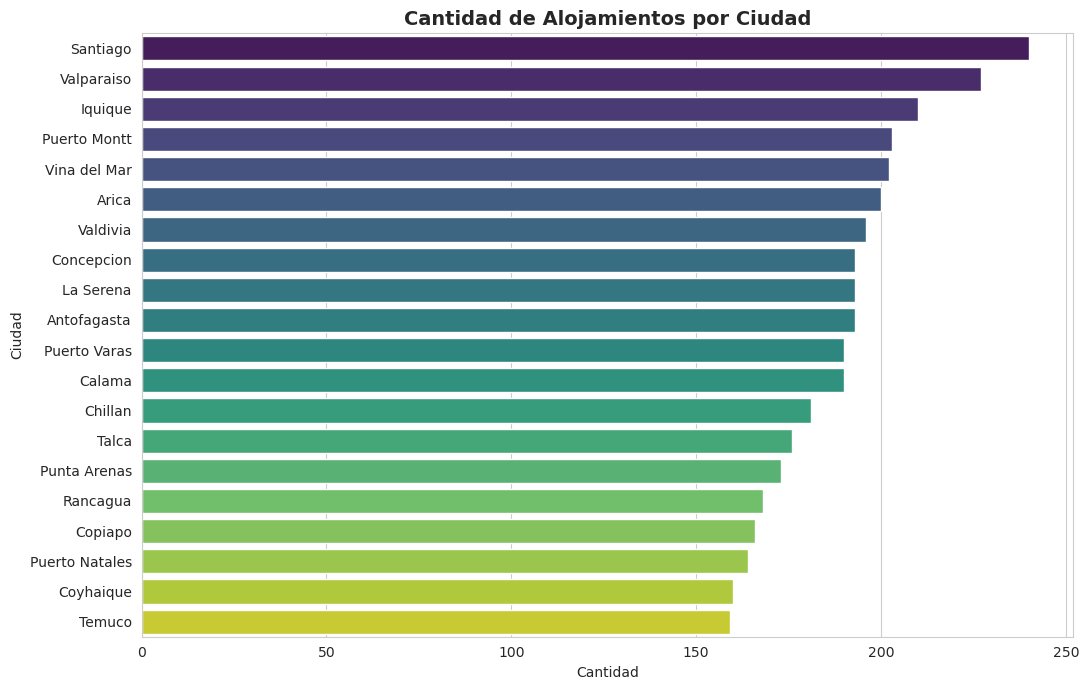

In [16]:
vc = pdf["ciudad"].value_counts().head(20)
plt.figure(figsize=(11,7))
sns.barplot(x=vc.values, y=vc.index, palette="viridis")
plt.title("Cantidad de Alojamientos por Ciudad", fontsize=14, fontweight="bold")
plt.xlabel("Cantidad"); plt.ylabel("Ciudad")
plt.tight_layout(); plt.show()

### 5. Zona geográfica
Cuántos alojamientos hay por zona del país.

/tmp/ipykernel_44482/1963749673.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.values, y=vc.index, palette="mako")


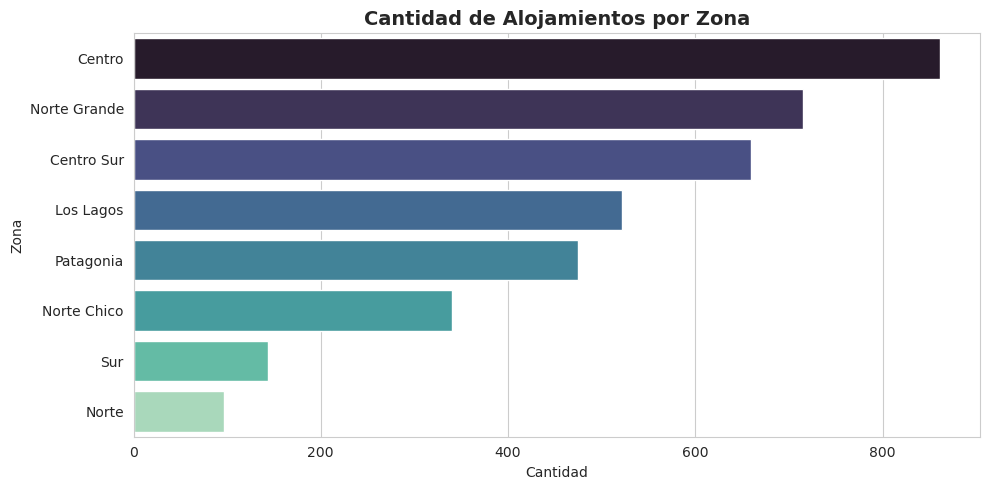

In [17]:
vc = pdf["zona_geografica"].value_counts()
plt.figure(figsize=(10,5))
sns.barplot(x=vc.values, y=vc.index, palette="mako")
plt.title("Cantidad de Alojamientos por Zona", fontsize=14, fontweight="bold")
plt.xlabel("Cantidad"); plt.ylabel("Zona")
plt.tight_layout(); plt.show()

### 6. Plataforma
De qué plataformas vienen los datos.

/tmp/ipykernel_44482/4015368520.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.values, y=vc.index, palette="flare")


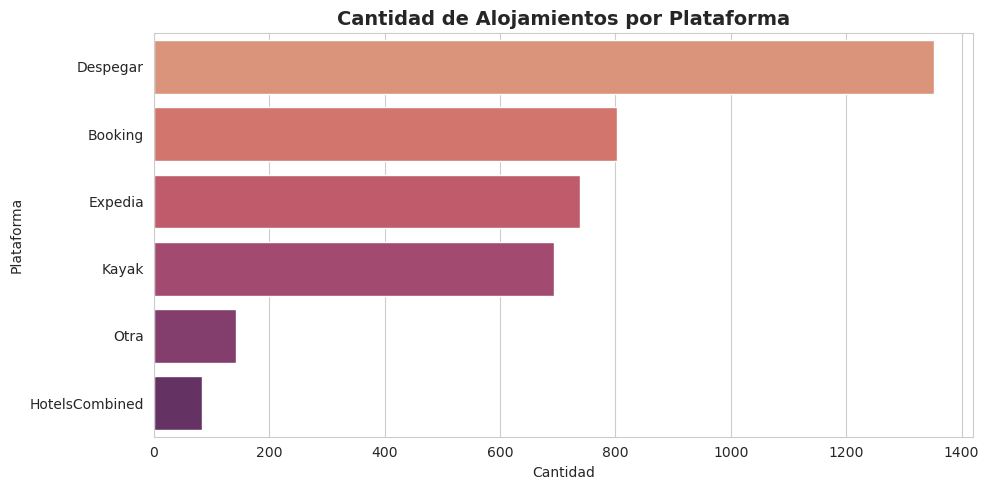

In [18]:
vc = pdf["plataforma"].value_counts()
plt.figure(figsize=(10,5))
sns.barplot(x=vc.values, y=vc.index, palette="flare")
plt.title("Cantidad de Alojamientos por Plataforma", fontsize=14, fontweight="bold")
plt.xlabel("Cantidad"); plt.ylabel("Plataforma")
plt.tight_layout(); plt.show()

### 7. Tipo de alojamiento
Qué tipos de alojamiento hay y cuántos de cada uno.

/tmp/ipykernel_44482/857924555.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vc.values, y=vc.index, palette="crest")


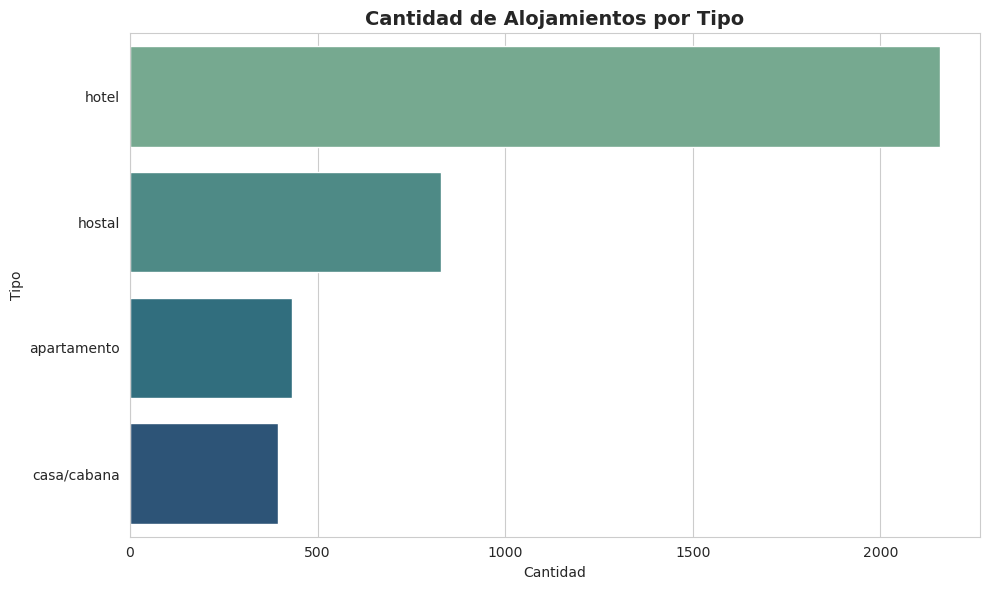

In [19]:
vc = pdf["tipo_alojamiento"].value_counts()
plt.figure(figsize=(10,6))
sns.barplot(x=vc.values, y=vc.index, palette="crest")
plt.title("Cantidad de Alojamientos por Tipo", fontsize=14, fontweight="bold")
plt.xlabel("Cantidad"); plt.ylabel("Tipo")
plt.tight_layout(); plt.show()

## Cómo se relacionan las variables

Hasta aquí miramos cada variable por separado. Ahora cruzamos las que responden preguntas reales para decidir una inversión. Lo principal es el tipo de alojamiento, así que partimos por ahí.

### Precio promedio por tipo de alojamiento
El cruce más importante: qué tipo de alojamiento se cobra más caro (hotel, hostal, apartamento, casa/cabaña). Responde en qué tipo conviene invertir según el ingreso por noche.

/tmp/ipykernel_44482/1904290951.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=precio_tipo.values, y=precio_tipo.index, palette="rocket_r")


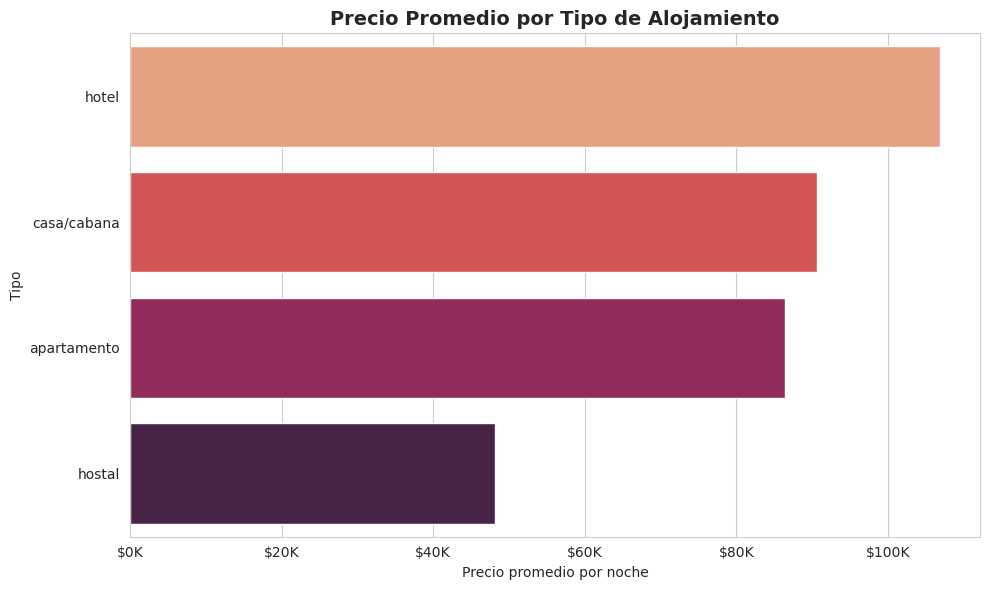

In [20]:
precio_tipo = pdf.groupby("tipo_alojamiento")["precio_clp"].mean().sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=precio_tipo.values, y=precio_tipo.index, palette="rocket_r")
ax = plt.gca()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f"${x/1000:.0f}K"))
plt.title("Precio Promedio por Tipo de Alojamiento", fontsize=14, fontweight="bold")
plt.xlabel("Precio promedio por noche"); plt.ylabel("Tipo")
plt.tight_layout(); plt.show()

### Precio promedio por ciudad
En qué ciudades se cobra más por noche. Sirve para ubicar los mercados más caros y los más económicos.

/tmp/ipykernel_44482/2540415488.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=precio_ciudad.values, y=precio_ciudad.index, palette="magma")


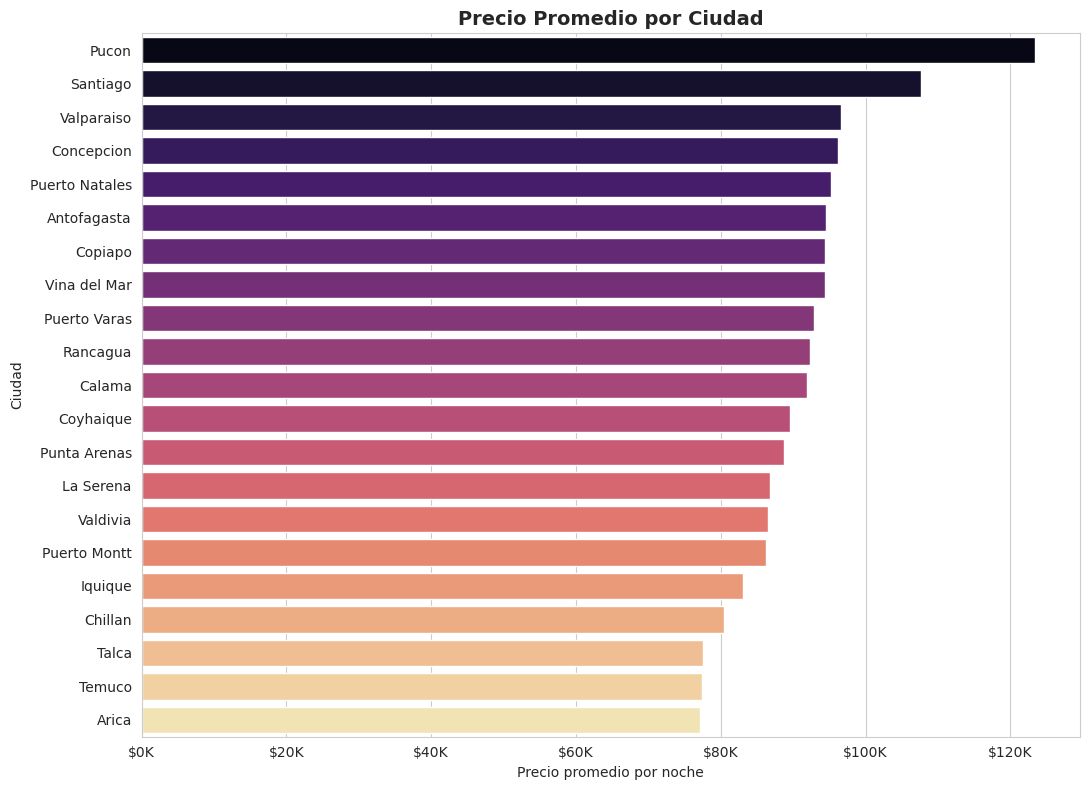

In [21]:
precio_ciudad = pdf.groupby("ciudad")["precio_clp"].mean().sort_values(ascending=False)
plt.figure(figsize=(11,8))
sns.barplot(x=precio_ciudad.values, y=precio_ciudad.index, palette="magma")
ax = plt.gca()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f"${x/1000:.0f}K"))
plt.title("Precio Promedio por Ciudad", fontsize=14, fontweight="bold")
plt.xlabel("Precio promedio por noche"); plt.ylabel("Ciudad")
plt.tight_layout(); plt.show()

### Precio promedio según estrellas
Como las estrellas van en orden (2 a 5), una línea muestra bien la tendencia: si subir de categoría se traduce en mayor precio. Responde si vale la pena invertir en más estrellas.

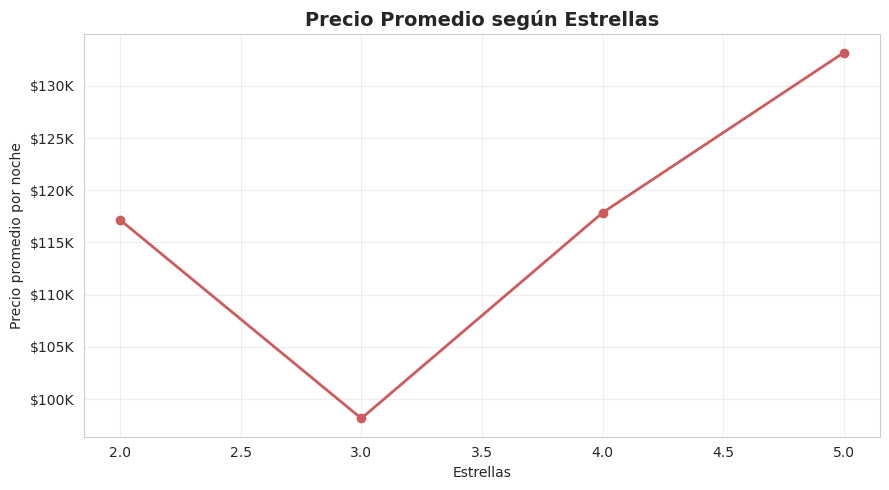

In [22]:
precio_estrellas = pdf.dropna(subset=["estrellas"]).groupby("estrellas")["precio_clp"].mean()
plt.figure(figsize=(9,5))
plt.plot(precio_estrellas.index, precio_estrellas.values, marker="o", color="indianred", linewidth=2)
ax = plt.gca()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f"${x/1000:.0f}K"))
plt.title("Precio Promedio según Estrellas", fontsize=14, fontweight="bold")
plt.xlabel("Estrellas"); plt.ylabel("Precio promedio por noche")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

### Puntuación promedio por tipo de alojamiento
Vemos qué tipo de alojamiento tiene mejor calidad percibida por el cliente. Conecta con lo principal (el tipo) y ayuda a ver si el tipo más caro también es el mejor evaluado.

/tmp/ipykernel_44482/3799060213.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=punt_tipo.values, y=punt_tipo.index, palette="rocket")


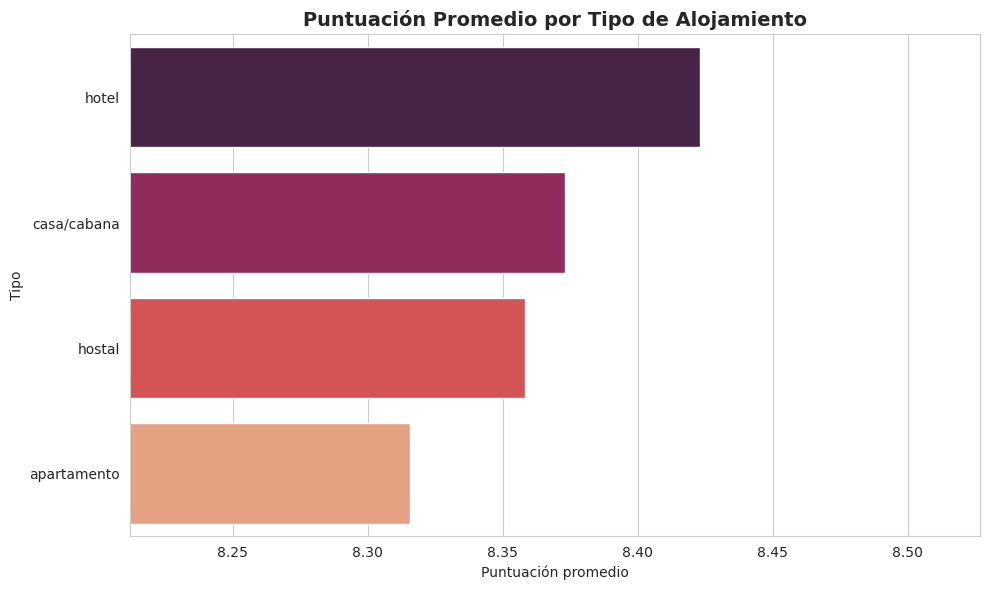

In [23]:
punt_tipo = pdf.groupby("tipo_alojamiento")["puntuacion"].mean().sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=punt_tipo.values, y=punt_tipo.index, palette="rocket")
plt.title("Puntuación Promedio por Tipo de Alojamiento", fontsize=14, fontweight="bold")
plt.xlabel("Puntuación promedio"); plt.ylabel("Tipo")
margen = (punt_tipo.max() - punt_tipo.min()) * 0.5 + 0.05
plt.xlim(punt_tipo.min() - margen, punt_tipo.max() + margen)
plt.tight_layout(); plt.show()

# Evaluación: ¿cuáles columnas sirven para el clustering?

El clustering (K-Means) agrupa por distancia entre valores numéricos, así que solo elegimos columnas que no le causen problemas: deben ser numéricas, sin nulos, en escalas comparables (se normalizan antes) y que no repitan la misma información.

**Entran al clustering:**

- **precio_clp:** cuánto cuesta el alojamiento. Numérica y sin nulos.
- **puntuacion:** la calidad percibida por el cliente. Quitamos las pocas filas sin puntuación para que no falle el modelo.
- **desvio_precio_ciudad:** si el alojamiento es caro o barato respecto a su ciudad. Mete el efecto de la ciudad como número.
- **desvio_precio_tipo:** si es caro o barato respecto a su mismo tipo. Mete el tipo (lo principal del proyecto) como número, sin usar texto.

Las cuatro son numéricas, sin nulos y miden cosas distintas (precio, calidad, posición en su ciudad y en su tipo), así que no se pisan entre sí.

**No entran al clustering:**

- **Ciudad, tipo, plataforma, zona:** son texto. El clustering no las mide por distancia. Su efecto ya queda recogido en los desvíos (ciudad en desvio_precio_ciudad, tipo en desvio_precio_tipo). Zona además se excluye por instrucción de la profe.
- **Estrellas:** tiene demasiados nulos (los apartamentos no se clasifican), usarla rompería los grupos.

**Resumen:** el clustering usa precio_clp, puntuacion, desvio_precio_ciudad y desvio_precio_tipo, normalizadas. Solo se crean las columnas derivadas que de verdad se usan.

# Crear las columnas nuevas (numéricas) para el clustering



### Desvío de precio vs su ciudad (%)

In [24]:
w_ciudad = Window.partitionBy("ciudad")
df = df.withColumn("promedio_ciudad", avg("precio_clp").over(w_ciudad))
df = df.withColumn("desvio_precio_ciudad",
    spark_round(((col("precio_clp") / col("promedio_ciudad")) - 1) * 100))
df.select("nombre_hotel","ciudad","precio_clp","desvio_precio_ciudad").show(8, truncate=False)

+---------------------------------------------+-----------+----------+--------------------+
|nombre_hotel                                 |ciudad     |precio_clp|desvio_precio_ciudad|
+---------------------------------------------+-----------+----------+--------------------+
|Hostal Norte Antofagasta                     |Antofagasta|44990.0   |-52.0               |
|Hotel Antofagasta                            |Antofagasta|82923.0   |-12.0               |
|Hostal Vista Hermosa Antofagasta             |Antofagasta|34879.0   |-63.0               |
|Park Inn by Radisson                         |Antofagasta|63738.0   |-33.0               |
|Hostal Plaza Antofagasta                     |Antofagasta|39163.0   |-59.0               |
|Residencial Primavera Antofagasta            |Antofagasta|36371.0   |-62.0               |
|Experiencia Vista Horizonte 2Hab-2Baño-1Estac|Antofagasta|199176.0  |111.0               |
|Lodge Del Mar Antofagasta                    |Antofagasta|81686.0   |-14.0     

### Desvío de precio vs su tipo (%)


In [25]:
w_tipo = Window.partitionBy("tipo_alojamiento")
df = df.withColumn("promedio_tipo", avg("precio_clp").over(w_tipo))
df = df.withColumn("desvio_precio_tipo",
    spark_round(((col("precio_clp") / col("promedio_tipo")) - 1) * 100))

# Para el clustering la puntuacion no puede tener nulos: quitamos esas filas
antes = df.count()
df = df.filter(col("puntuacion").isNotNull())
print(f"Eliminadas filas sin puntuacion: {antes - df.count()}  ->  quedan {df.count()}")

df.select("nombre_hotel","tipo_alojamiento","precio_clp",
          "desvio_precio_ciudad","desvio_precio_tipo","puntuacion").show(8, truncate=False)

Eliminadas filas sin puntuacion: 229  ->  quedan 3584
+---------------------------------+----------------+----------+--------------------+------------------+----------+
|nombre_hotel                     |tipo_alojamiento|precio_clp|desvio_precio_ciudad|desvio_precio_tipo|puntuacion|
+---------------------------------+----------------+----------+--------------------+------------------+----------+
|Apart Hotel Andino Antofagasta   |apartamento     |82822.0   |-12.0               |-4.0              |7.0       |
|Apart Hotel Andino Antofagasta   |apartamento     |79329.0   |-16.0               |-8.0              |7.1       |
|Apart Hotel Astore               |apartamento     |158700.0  |68.0                |84.0              |7.1       |
|Apart Hotel Central Antofagasta  |apartamento     |80781.0   |-15.0               |-6.0              |9.5       |
|Apart Hotel Central Antofagasta  |apartamento     |118247.0  |25.0                |37.0              |7.3       |
|Apart Hotel Costanera Ant

# Guardar datos limpios en processed_data

In [26]:
columnas_finales = ["nombre_hotel", "ciudad", "tipo_alojamiento", "precio_clp",
                    "puntuacion", "estrellas", "desvio_precio_ciudad",
                    "desvio_precio_tipo", "zona_geografica", "plataforma"]
df_final = df.select(columnas_finales)

df_final.write.format("mongodb") \
    .option("database", "proyecto_bigdata") \
    .option("collection", "processed_data") \
    .mode("overwrite") \
    .save()
print("Guardado en processed_data. Registros:", df_final.count())
print("Columnas:", df_final.columns)

Guardado en processed_data. Registros: 3584
Columnas: ['nombre_hotel', 'ciudad', 'tipo_alojamiento', 'precio_clp', 'puntuacion', 'estrellas', 'desvio_precio_ciudad', 'desvio_precio_tipo', 'zona_geografica', 'plataforma']
